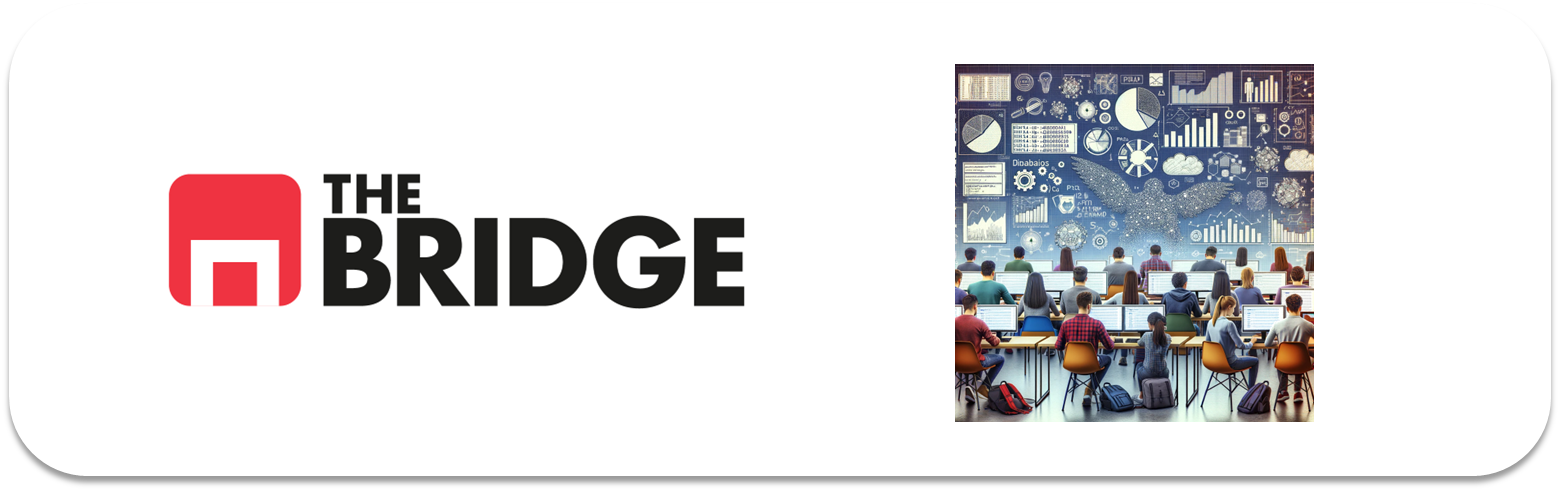

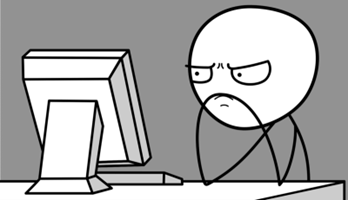

Para ejercitarte y afianzar lo aprendido sobre **Regularización**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

En estos ejercicios vamos a repasar la regularización sobre regresión lineal obteniendo primero un modelo de regresión lineal para predecir el precio de un coche y luego los equivalentes con penalizaciones L2 (Ridge), L1 (Lasso) y con la combinación de ambas (ElasticNet)

### Ejercicio 1

Carga el dataset de partida ("./data/CarPrice_Assignment.csv") en el que tenemos diferentes modelos de coches con sus características y el precio de estos. Échale un vistazo

In [3]:
df = pd.read_csv("./data/CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

### Ejercicio 2

Identifica la variable target y asignala a una variable de nombre `target`, luego elimina de forma permanente el campo "car_ID"

In [5]:
target = df["price"]
print(len(target))
df = df.drop(columns= "car_ID")

205


In [6]:
print(df.columns)

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')


In [7]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### Ejercicio 3

Haz un split del dataset en train y test al 80/20 empleando la función de sklearn que ya conoces

In [8]:
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)
print(df.shape)
print(train_set.shape)
print(test_set.shape)


(205, 25)
(164, 25)
(41, 25)


### Ejercicio 4

Aunque vamos a emplear todas las variabes numéricas del dataset como predictores o features, obten la correlación de todas ellas con el target y escoge los que creas que son tus tres mejores predictores. Crea una lista con los nombres de las variables numéricas y llámalo `features_num`

In [12]:
feature_num = train_set[['symboling', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginesize', 
       'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg']].copy()

In [15]:
print(feature_num.corrwith(target))

symboling          -0.005183
wheelbase           0.506118
carlength           0.652071
carwidth            0.744310
carheight           0.044458
curbweight          0.824212
enginesize          0.866433
boreratio           0.546099
stroke              0.023941
compressionratio    0.035218
horsepower          0.810986
peakrpm            -0.070017
citympg            -0.711245
highwaympg         -0.713503
combined_mpg       -0.718768
dtype: float64


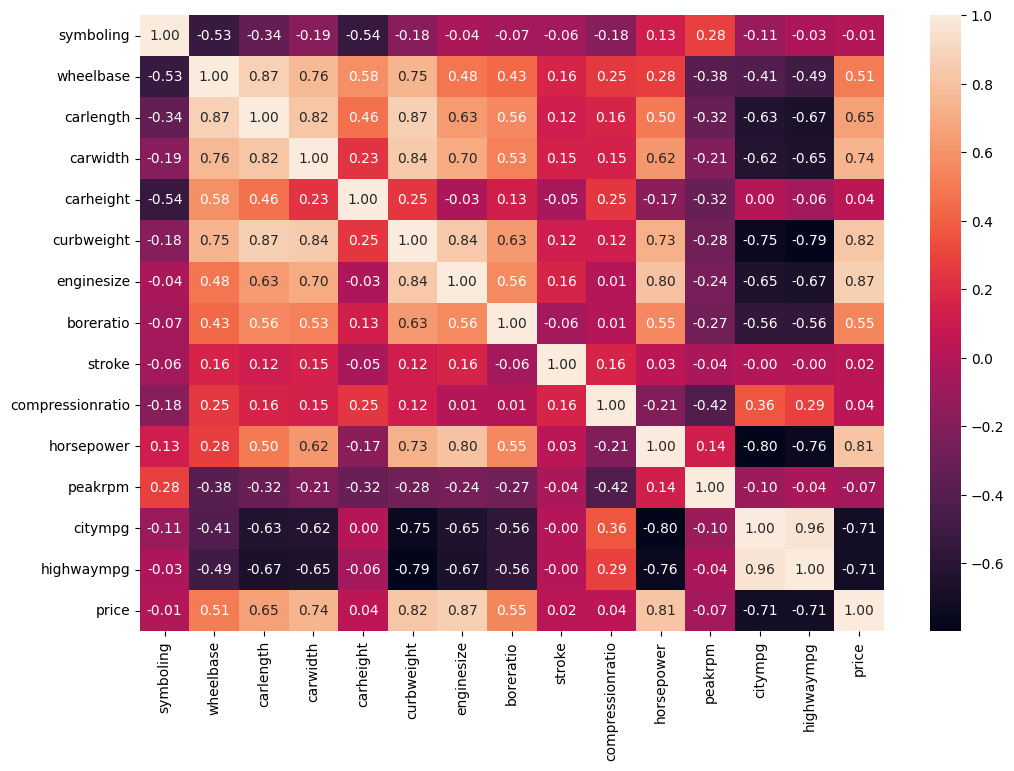

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_set.corr(numeric_only = True),annot=True, fmt=".2f");
plt.show();

In [14]:
feature_num["combined_mpg"]= feature_num["highwaympg"]*0.55 + feature_num["citympg"]*0.45

In [17]:
print(len(train_set))
print(len(feature_num))

164
164


In [18]:
train_set["combined_mpg"] = feature_num["combined_mpg"]

In [19]:
train_set.columns
# Otra manera de comprobarlo print("combined_mpg" in train_set.columns) 

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price',
       'combined_mpg'],
      dtype='object')

In [20]:
test_set["combined_mpg"]= test_set["highwaympg"]*0.55 + test_set["citympg"]*0.45

In [22]:
print("combined_mpg" in test_set.columns) 

True


Mis tres mejores predictores:  
enginesize           0.866433  
combined_mpg        -0.718768  
curbweight           0.824212

### Ejercicio 5

Completa el siguiente código que tiene como objetivo generar un modelo de regresión lineal utilizando todos los valores de las variables (salvo la target):

In [28]:
# Separación x e y
X_train = train_set.drop(columns= ["price"])
y_train = train_set["price"]

X_test = test_set.drop(columns = ["price"])
y_test = test_set["price"]

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train[feature_num.columns]), columns= feature_num.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test[feature_num.columns]), columns= feature_num.columns, index= X_test.index)

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Ejercicio 6

Obten el MAE,RMSE y $R^2$ para las predicciones sobre train (X_train) y para las predicciones sobre test (X_test). ¿Podemos esperar una buena generalización?

In [29]:
pred_train = lin_reg.predict(X_train)
pred_test = lin_reg.predict(X_test)

In [30]:
print('MAE train', metrics.mean_absolute_error(y_train, pred_train))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, pred_train)))
print('R2 train', lin_reg.score(X_train,y_train))

MAE train 2186.4952386197665
RMSE train 2911.593458582073
R2 train 0.8578523829898764


In [31]:
print('MAE test', metrics.mean_absolute_error(y_test, pred_test))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, pred_test)))
print('R2 test', lin_reg.score(X_test,y_test))

MAE test 2680.4299831594226
RMSE test 3789.199007303312
R2 test 0.818123919241005


### Ejercicio 7
 
Vamos a regularizar, crea un regresor Ridge con alpha inicial a 10 y entrenalo con el X_train. Obten MAE, RMSE y $R^2$ considerando las predicciones sobre el mismo X_train

In [57]:
ridgeR = Ridge(alpha= 1)
ridgeR.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [43]:
print('MAE train', round(metrics.mean_absolute_error(y_train, ridgeR.predict(X_train)), 2))
print('RMSE train', round(np.sqrt(metrics.mean_squared_error(y_train,ridgeR.predict(X_train))),2))
print('R2 train', ridgeR.score(X_train,y_train))

MAE train 2158.99
RMSE train 2943.01
R2 train 0.8547677687882148


### Ejercicio 8

Evalúalo contra el X_test y obten MAE,RMSE y $R^2$. ¿Es mejor generalizado que la regresión lineal sin regularizar?

In [59]:
print('MAE test', round(metrics.mean_absolute_error(y_test, ridgeR.predict(X_test)), 2))
print('RMSE test', round(np.sqrt(metrics.mean_squared_error(y_test,ridgeR.predict(X_test))),2))
print('R2 test', ridgeR.score(X_test,y_test))

MAE test 2664.94
RMSE test 3755.32
R2 test 0.8213620681582503


El modelo mejora.

### Ejercicio 9
 
Ahora crea un regresor Lasso con alpha inicial a 125 y entrenalo con el X_train. Obten MAE, RMSE y $R^2$ considerando las predicciones sobre el mismo X_train.

In [68]:
lassoR = Lasso(alpha = 125) 
lassoR.fit(X_train, y_train)

print('MAE train', round(metrics.mean_absolute_error(y_train, lassoR.predict(X_train)), 2))
print('RMSE train', round(np.sqrt(metrics.mean_squared_error(y_train,lassoR.predict(X_train))),2))
print('R2 train', round(lassoR.score(X_train,y_train),2))

MAE train 2160.77
RMSE train 2979.46
R2 train 0.85


### Ejercicio 10

Evalúalo contra el X_test y obten MAE,RMSE y $R^2$. ¿Es mejor generalizado que los otros dos modelos?

In [69]:
print('MAE test', round(metrics.mean_absolute_error(y_test, lassoR.predict(X_test)), 2))
print('RMSE test', round(np.sqrt(metrics.mean_squared_error(y_test,lassoR.predict(X_test))),2))
print('R2 test', round(lassoR.score(X_test,y_test),2))

MAE test 2720.01
RMSE test 3767.75
R2 test 0.82


MAE test 2680.4299831594226  
RMSE test 3789.199007303312  
R2 test 0.818123919241005

### Ejercicio 11

Repite los ejercicios 9 y 10 con un regresor ElasticNet con alpha 0.2 y l1_ratio a 0.7. ¿Es mejor generalizando que el resto?

In [73]:
elastic_net = ElasticNet(alpha = 0.2, l1_ratio = 0.9)
elastic_net.fit(X_train, y_train)

print('MAE train', round(metrics.mean_absolute_error(y_train, elastic_net.predict(X_train)), 2))
print('RMSE train', round(np.sqrt(metrics.mean_squared_error(y_train,elastic_net.predict(X_train))),2))
print('R2 train', round(elastic_net.score(X_train,y_train),2))

print('MAE test', round(metrics.mean_absolute_error(y_test, elastic_net.predict(X_test)), 2))
print('RMSE test', round(np.sqrt(metrics.mean_squared_error(y_test,elastic_net.predict(X_test))),2))
print('R2 test', round(elastic_net.score(X_test,y_test),2))



MAE train 2161.01
RMSE train 2930.6
R2 train 0.86
MAE test 2653.83
RMSE test 3730.9
R2 test 0.82


### Ejercicio 12

¿Qué podrías hacer para mejorar los regresores regularizados?

### EXTRA:

Utiliza la función siguiente para pintar la importancia de los coeficientes en cada uno de los cuatro modelos y observa el efecto de las penalizaciones de cada una de las regularizaciones:

In [74]:
def show_coefs(model, figsize=(10, 5)):
    df_coef = pd.DataFrame(model.coef_, index=model.feature_names_in_, columns=["coefs"])

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    df_coef.plot(kind="barh", ax=ax[0], legend=False)
    df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
    fig.suptitle("Model Coefficients")

    fig.tight_layout()

    return df_coef

,coefs
symboling,259.207046
wheelbase,835.387850
carlength,-937.566044
carwidth,1112.646820
carheight,497.057372
curbweight,227.500700
enginesize,4976.563274
boreratio,-97.680684
stroke,-1010.387520
compressionratio,1387.225279


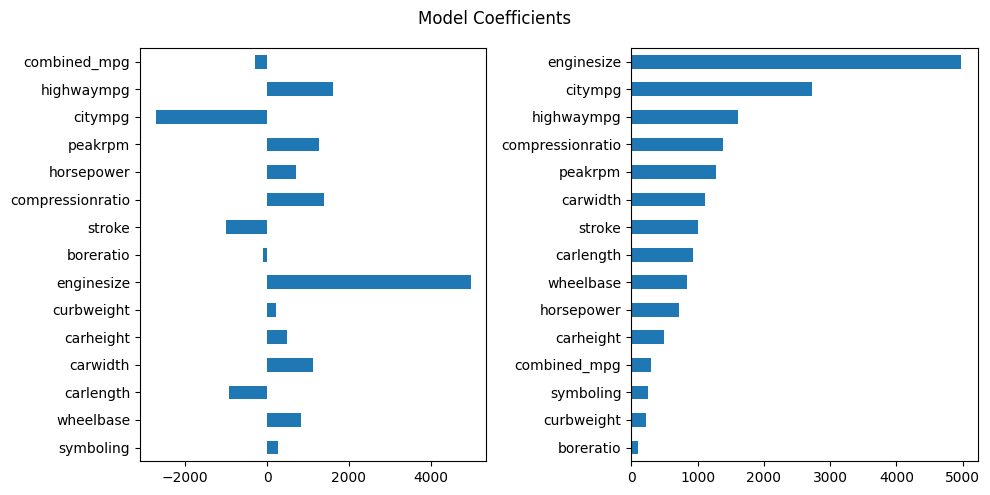

In [75]:
show_coefs(lin_reg)

,coefs
symboling,277.885193
wheelbase,722.618648
carlength,-784.826285
carwidth,1112.200341
carheight,470.115676
curbweight,329.876701
enginesize,4735.756579
boreratio,-89.777518
stroke,-970.765305
compressionratio,1303.101970


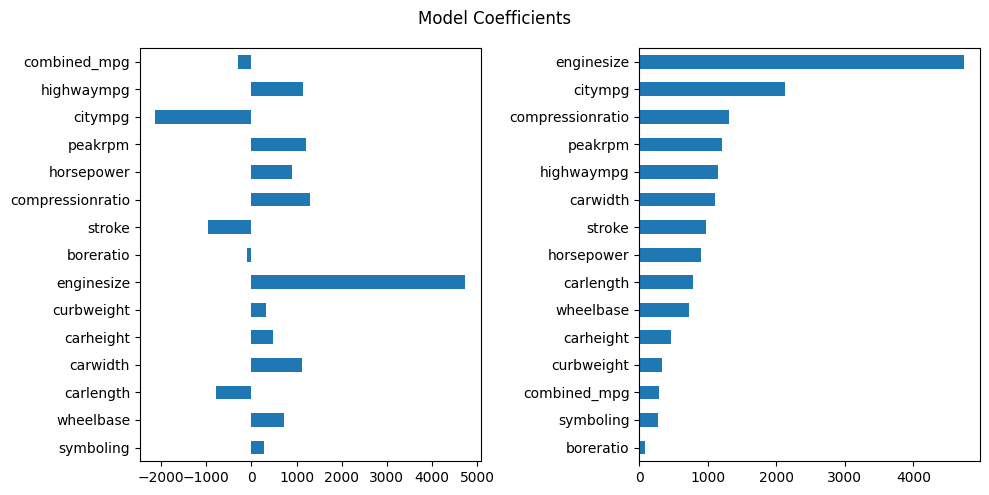

In [76]:
show_coefs(ridgeR)

,coefs
symboling,3.897387
wheelbase,0.000000
carlength,0.000000
carwidth,1185.253288
carheight,193.993785
curbweight,260.713690
enginesize,4368.898684
boreratio,0.000000
stroke,-754.360885
compressionratio,965.709886


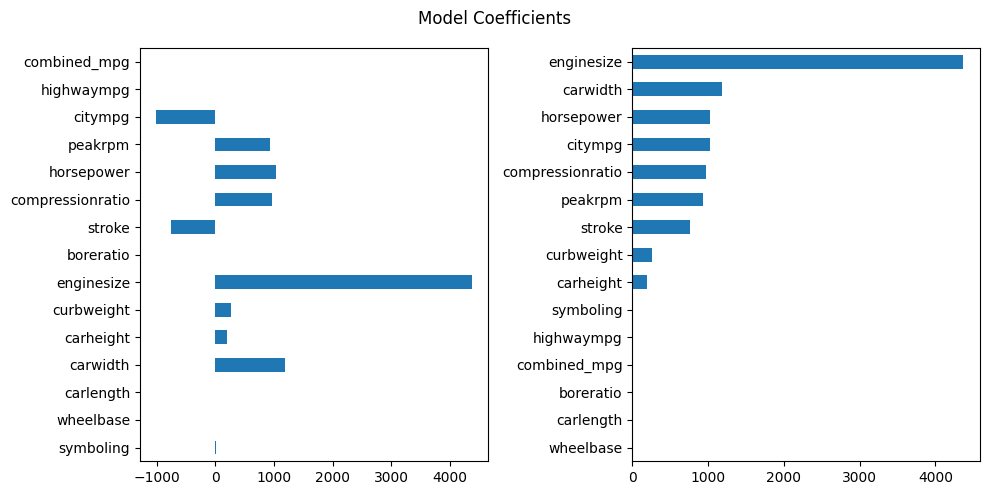

In [77]:
show_coefs(lassoR)

,coefs
symboling,294.213778
wheelbase,571.182239
carlength,-569.259285
carwidth,1103.510887
carheight,413.681454
curbweight,509.574570
enginesize,4341.601497
boreratio,-76.497535
stroke,-907.976490
compressionratio,1182.355854


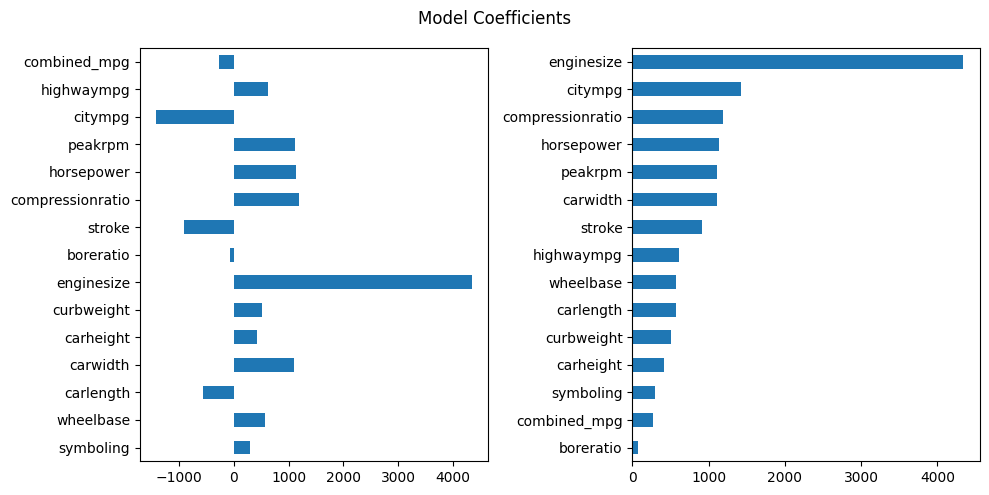

In [78]:
show_coefs(elastic_net)